In [ ]:
"""
=============================================================================
OPTIMIZATION OF BORING BAR DYNAMICS — PARAMETER 1: CAVITY POSITION
=============================================================================
Problem statement (from assignment image)
─────────────────────────────────────────
Rotary boring bar with tuned mass damper.
Objective  : Maximize limiting depth of cut (stability)
Parameter 1: Position of the damper cavity

GEOMETRY — 5 sections
───────────────────────
  Sec 1  [0,       L1]         : Hollow cylinder, large outer dia D1 (flange)
  Sec 2  [L1,      L1+L2]      : Tapered hollow cylinder (D1 → D_main)
  Sec 3  [L1+L2,   L1+L2+L3]  : Hollow cylinder, D_main, di_body  ← L3 is swept
  Sec 4  [L1+L2+L3, …+L4]     : Hollow cylinder, D_main, di_cav   ← houses damper
  Sec 5  [… ,      L_total]    : Solid cylinder, D_main (cutting tip)

  Outer diameters of sections 3, 4, 5 are identical (D_main).

MATERIAL ASSUMPTIONS
─────────────────────
  Body    : E = 280 GPa,  ρ = 1.2 × ρ_steel = 9420 kg/m³
  Damper  : Tungsten Carbide, ρ_WC = 14 500 kg/m³
  Oil     : Damping ratio ζ_oil = 0.3  (used as absorber damping ratio)

KEY PHYSICS
────────────
  • Single-mode approximation for first bending mode (Patel et al. 2022)
  • Gyroscopic, Coriolis, centrifugal, rotational-inertia effects (Eq. 28)
  • Speed-dependent FRF at each pocket speed (proposed non-zero-speed method)
  • Budak-Altintas stability lobe diagram (pocket-speed algorithm)
  • Den Hartog optimal absorber tuning at each position
  • Results: fn1, modal mass, PSI(zd), optimal kd/cd, alim improvement,
    stability lobes, mode shape, FRF comparison
=============================================================================
"""

import numpy as np
from scipy.optimize import brentq, minimize
from scipy.integrate import quad
from scipy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.  MATERIAL AND GEOMETRIC CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════

E_body   = 280e9            # Pa   body modulus (~280 GPa as stated)
rho_body = 7850 * 1.2       # kg/m³  body density (steel × 1.2)
rho_WC   = 14_500.0         # kg/m³  tungsten carbide damper
zeta_oil = 0.3              # —     oil damping ratio (given)
zeta0    = 0.01             # —     structural damping ratio (1 %)

# Nominal geometry (fixed)
L_total  = 0.400            # m     total bar length
D1_out   = 0.063            # m     section-1 outer dia (flange, HSK-63 style)
D_main   = 0.050            # m     sections 3-4-5 outer dia
di_body  = 0.020            # m     hollow inner dia (sections 1-2-3)
wall_min = 0.003            # m     minimum wall thickness in cavity (section 4)
di_cav   = D_main - 2*wall_min   # 0.044 m  cavity inner dia
gap_rad  = 0.001            # m     radial gap between damper and cavity wall
d_damper = di_cav - 2*gap_rad    # 0.042 m  damper mass outer dia

L1       = 0.040            # m     flange length
L2       = 0.030            # m     taper length
L4       = 0.100            # m     cavity length (fixed for position sweep)
L5       = 0.030            # m     solid tip length

# Cavity position parameter: L3 = length of hollow section BEFORE cavity
L3_min   = 0.000            # m
L3_max   = L_total - L1 - L2 - L4 - L5   # = 0.100 m

# Milling / boring parameters
Nt       = 5                # number of inserts (boring bar typically 1–2)
Ktc      = 2000e6           # Pa   tangential cutting coeff (steel boring)
Krc      = 500e6            # Pa   radial cutting coeff
ratio_kr = Krc / Ktc        # 0.25

print("=" * 65)
print("BORING BAR CAVITY POSITION OPTIMIZATION")
print("=" * 65)
print(f"  Total length     = {L_total*1e3:.0f} mm")
print(f"  D_main           = {D_main*1e3:.0f} mm")
print(f"  Cavity ID        = {di_cav*1e3:.0f} mm  (wall = {wall_min*1e3:.0f} mm)")
print(f"  Damper dia       = {d_damper*1e3:.0f} mm  (1 mm gap)")
print(f"  L3 sweep range   = [{L3_min*1e3:.0f}, {L3_max*1e3:.0f}] mm")
print(f"  zd range (center)= [{(L1+L2+L3_min+L4/2)*1e3:.0f}, {(L1+L2+L3_max+L4/2)*1e3:.0f}] mm")

BORING BAR CAVITY POSITION OPTIMIZATION
  Total length     = 400 mm
  D_main           = 50 mm
  Cavity ID        = 44 mm  (wall = 3 mm)
  Damper dia       = 42 mm  (1 mm gap)
  L3 sweep range   = [0, 200] mm
  zd range (center)= [120, 320] mm


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.  CROSS-SECTION PROPERTIES
# ═══════════════════════════════════════════════════════════════════════════

def cross_section(D_out, d_in=0.0):
    """Return (A, I, Ip) for hollow/solid circular cross-section."""
    ro, ri = D_out/2, d_in/2
    A  = np.pi * (ro**2  - ri**2)
    I  = np.pi * (ro**4  - ri**4) / 4
    Ip = np.pi * (ro**4  - ri**4) / 2
    return A, I, Ip

# Fixed-section properties
A1s, I1s, Ip1s = cross_section(D1_out, di_body)
A3s, I3s, Ip3s = cross_section(D_main, di_body)
A4s, I4s, Ip4s = cross_section(D_main, di_cav)
A5s, I5s, Ip5s = cross_section(D_main, 0.0)

# Taper section 2: average over linear diameter transition
_fracs = np.linspace(0, 1, 400)
_D2    = D1_out + (D_main - D1_out) * _fracs
A2s    = np.mean([cross_section(d, di_body)[0] for d in _D2])
I2s    = np.mean([cross_section(d, di_body)[1] for d in _D2])
Ip2s   = np.mean([cross_section(d, di_body)[2] for d in _D2])

# Per-section arrays (indices 0-4 = sections 1-5)
EI_sec   = np.array([E_body*I1s,  E_body*I2s,  E_body*I3s,  E_body*I4s,  E_body*I5s])
rhoA_sec = np.array([rho_body*A1s, rho_body*A2s, rho_body*A3s, rho_body*A4s, rho_body*A5s])
rhoI_sec = np.array([rho_body*I1s, rho_body*I2s, rho_body*I3s, rho_body*I4s, rho_body*I5s])
rhoIp_sec= np.array([rho_body*Ip1s, rho_body*Ip2s, rho_body*Ip3s, rho_body*Ip4s, rho_body*Ip5s])

# Wave-speed array  ci = sqrt(EIi / rhoAi)
c_sec    = np.sqrt(EI_sec / rhoA_sec)

# Damper mass (fixed size, material WC)
L_damper = L4 - 0.010          # 5 mm clearance each end
A_damp, _, _ = cross_section(d_damper, 0.0)
md       = rho_WC * A_damp * L_damper
print(f"\n  Damper mass md   = {md:.4f} kg  (WC, {L_damper*1e3:.0f} mm long)")


  Damper mass md   = 1.8080 kg  (WC, 90 mm long)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.  FIVE-SECTION CHARACTERISTIC MATRIX  (20 × 20)
# ═══════════════════════════════════════════════════════════════════════════
# Euler-Bernoulli beam mode shape in section i:
#   ψᵢ(z) = C₁ᵢ cos(βᵢz) + C₂ᵢ cosh(βᵢz) + C₃ᵢ sin(βᵢz) + C₄ᵢ sinh(βᵢz)
#   where ωₙ = βᵢ² √(EIᵢ/ρAᵢ)  →  βᵢ = √(ωₙ / cᵢ)
#
# 20 unknowns: 4 coefficients × 5 sections
# 20 equations: 2 BCs at fixed end + 2 BCs at free end + 4×4 interface conditions

def beam_basis(b, z):
    return np.array([np.cos(b*z),  np.cosh(b*z),  np.sin(b*z),  np.sinh(b*z)])
def d1_basis(b, z):
    return np.array([-b*np.sin(b*z), b*np.sinh(b*z),  b*np.cos(b*z), b*np.cosh(b*z)])
def d2_basis(b, z):
    return np.array([-b**2*np.cos(b*z),  b**2*np.cosh(b*z),
                     -b**2*np.sin(b*z),  b**2*np.sinh(b*z)])
def d3_basis(b, z):
    return np.array([b**3*np.sin(b*z),   b**3*np.sinh(b*z),
                    -b**3*np.cos(b*z),   b**3*np.cosh(b*z)])


def section_boundaries(L3):
    """Return [z0, z1, z2, z3, z4, z5] — boundary positions for given L3."""
    return [0,
            L1,
            L1 + L2,
            L1 + L2 + L3,
            L1 + L2 + L3 + L4,
            L_total]


def betas_from_omega(omega):
    """Wave numbers βᵢ for all 5 sections at angular frequency omega."""
    return np.sqrt(omega / c_sec)


def char_matrix_5s(omega, L3):
    """
    Build the 20×20 characteristic matrix.
    Rows 0-1   : fixed-end BCs  ψ₁(0)=0, ψ₁'(0)=0
    Rows 2-3   : free-end  BCs  EI₅ψ₅''(L)=0, EI₅ψ₅'''(L)=0
    Rows 4-19  : 4 interfaces × 4 continuity conditions each
    """
    zb = section_boundaries(L3)
    betas = betas_from_omega(omega)

    M = np.zeros((20, 20))
    row = 0

    # Fixed-end boundary conditions
    b = betas[0]
    M[row, 0:4] = beam_basis(b, zb[0]);  row += 1
    M[row, 0:4] =   d1_basis(b, zb[0]);  row += 1

    # Free-end boundary conditions
    b = betas[4]
    M[row, 16:20] = EI_sec[4] * d2_basis(b, zb[5]);  row += 1
    M[row, 16:20] = EI_sec[4] * d3_basis(b, zb[5]);  row += 1

    # Interface continuity at each of the 4 internal interfaces
    for k in range(4):
        z_int = zb[k + 1]
        bl    = betas[k];      br    = betas[k + 1]
        EIl   = EI_sec[k];     EIr   = EI_sec[k + 1]
        col_l = 4 * k;         col_r = 4 * (k + 1)

        # ψ continuity
        M[row, col_l:col_l+4] =  beam_basis(bl, z_int)
        M[row, col_r:col_r+4] = -beam_basis(br, z_int);   row += 1
        # ψ' continuity
        M[row, col_l:col_l+4] =  d1_basis(bl, z_int)
        M[row, col_r:col_r+4] = -d1_basis(br, z_int);    row += 1
        # EI ψ'' continuity (bending moment)
        M[row, col_l:col_l+4] =  EIl * d2_basis(bl, z_int)
        M[row, col_r:col_r+4] = -EIr * d2_basis(br, z_int); row += 1
        # EI ψ''' continuity (shear force)
        M[row, col_l:col_l+4] =  EIl * d3_basis(bl, z_int)
        M[row, col_r:col_r+4] = -EIr * d3_basis(br, z_int); row += 1

    return M


def det_sign(omega, L3):
    """Sign of det of characteristic matrix — used for root finding."""
    try:
        s, _ = np.linalg.slogdet(char_matrix_5s(omega, L3))
        return float(s)
    except Exception:
        return 0.0


def find_first_nat_freq(L3, n_scan=400_000, omega_lo=200.0, omega_hi=40_000.0):
    """Find first natural frequency (rad/s) of the 5-section beam for given L3."""
    scan   = np.linspace(omega_lo, omega_hi, n_scan)
    signs  = np.array([det_sign(om, L3) for om in scan])
    for i in range(len(signs) - 1):
        if signs[i] * signs[i+1] < 0 and signs[i] != 0 and signs[i+1] != 0:
            try:
                return brentq(lambda o: det_sign(o, L3),
                              scan[i], scan[i+1], xtol=0.1)
            except Exception:
                pass
    return None

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.  MODE SHAPE EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

def get_mode_shape(omega, L3):
    """
    Return a callable ψ(z) normalised so ψ(L_total) = 1,
    plus its derivative dψ/dz, from the SVD null vector.
    Also returns the 20 raw coefficients C and the z-boundaries.
    """
    M       = char_matrix_5s(omega, L3)
    _, _, Vh = svd(M)
    C       = Vh[-1]                   # null vector

    betas   = betas_from_omega(omega)
    zb      = section_boundaries(L3)

    def _raw(z):
        if   z <= zb[1]: return C[0:4]  @ beam_basis(betas[0], z)
        elif z <= zb[2]: return C[4:8]  @ beam_basis(betas[1], z)
        elif z <= zb[3]: return C[8:12] @ beam_basis(betas[2], z)
        elif z <= zb[4]: return C[12:16]@ beam_basis(betas[3], z)
        else:            return C[16:20] @ beam_basis(betas[4], z)

    def _draw(z):
        if   z <= zb[1]: return C[0:4]  @ d1_basis(betas[0], z)
        elif z <= zb[2]: return C[4:8]  @ d1_basis(betas[1], z)
        elif z <= zb[3]: return C[8:12] @ d1_basis(betas[2], z)
        elif z <= zb[4]: return C[12:16]@ d1_basis(betas[3], z)
        else:            return C[16:20] @ d1_basis(betas[4], z)

    scale = _raw(L_total)
    psi   = lambda z: _raw(z)  / scale
    dpsi  = lambda z: _draw(z) / scale
    return psi, dpsi, C, zb, betas

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.  MODAL INTEGRALS
# ═══════════════════════════════════════════════════════════════════════════
# Mm  = ∫ ρA(z) ψ²(z) dz
# Rii = ∫ ρI(z) ψ'²(z) dz   (rotational inertia)
# Gii = ∫ ρIp(z)ψ'²(z) dz   (gyroscopic)

def _sec_idx(z, zb):
    """Which section index (0-4) does z belong to?"""
    for k in range(4):
        if z <= zb[k+1]:
            return k
    return 4

def modal_integrals(psi_fn, dpsi_fn, zb):
    """Compute Mm, Rii, Gii by summing integrals over each section."""
    Mm_tot = 0.0;  Rii_tot = 0.0;  Gii_tot = 0.0
    for k in range(5):
        za, zb_k = zb[k], zb[k+1]
        rA  = rhoA_sec[k];  rI = rhoI_sec[k];  rIp = rhoIp_sec[k]
        Mm_tot  += quad(lambda z: rA  * psi_fn(z)**2,  za, zb_k, limit=200)[0]
        Rii_tot += quad(lambda z: rI  * dpsi_fn(z)**2, za, zb_k, limit=200)[0]
        Gii_tot += quad(lambda z: rIp * dpsi_fn(z)**2, za, zb_k, limit=200)[0]
    return Mm_tot, Rii_tot, Gii_tot

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6.  SYSTEM MATRICES — SINGLE-MODE Eq. (28) WITH ALL ROTATIONAL EFFECTS
# ═══════════════════════════════════════════════════════════════════════════
# State: {q_ui, u_d, q_vi, v_d}ᵀ  (4 × 4)
#
# FORCES INCLUDED (all non-zero speed terms):
#   [M]+[M]_R : beam modal mass + rotational inertia correction
#   [C]_str   : structural modal damping
#   [C]_Co    : Coriolis coupling (2Ω M_mm, skew-symmetric between u and v)
#   [C]_G     : Gyroscopic coupling (2Ω G_ii, same sign pattern as Coriolis)
#   [C]_d     : absorber damping
#   [K]       : modal stiffness
#   [K]_Ce    : centrifugal softening (−Ω² M_mm for beam, −Ω² md for absorber)
#   [K]_d     : absorber stiffness coupling (ψ(zd) outer product)

def build_4x4(Omega, Mm, Rii, Gii, Km, Cm_str, PSI_zd, kd, cd):
    """
    Assemble 4×4 M, D, K matrices for beam + absorber at spindle speed Omega.

    Parameters
    ----------
    Omega   : rad/s  spindle speed
    Mm      : modal mass of beam
    Rii     : rotational-inertia modal integral
    Gii     : gyroscopic modal integral
    Km      : modal stiffness
    Cm_str  : structural modal damping coefficient
    PSI_zd  : mode-shape value at absorber centre
    kd, cd  : absorber stiffness and damping
    """
    # Diagonal beam entries (with rotational effects)
    M11       = Mm + Rii                             # [M]+[M]_R
    K11_beam  = Km - Omega**2 * Mm                   # [K]+[K]_Ce (beam centrifugal)
    K11_abs   = kd - Omega**2 * md                   # absorber centrifugal
    # Off-diagonal Coriolis / Gyroscopic coupling
    Cor       = 2.0 * Omega * Mm                      # Coriolis  (u ↔ v)
    Gyr       = 2.0 * Omega * Gii                     # Gyroscopic
    C_off     = Cor - Gyr                             # net rotational coupling
    # Absorber Coriolis
    Cor_abs   = 2.0 * Omega * md

    M_mat = np.diag([M11, md, M11, md])

    K_mat = np.array([
        [K11_beam + kd*PSI_zd**2,  -kd*PSI_zd,              0.0,                       0.0       ],
        [-kd*PSI_zd,                K11_abs,                 0.0,                       0.0       ],
        [0.0,                       0.0,        K11_beam + kd*PSI_zd**2,   -kd*PSI_zd            ],
        [0.0,                       0.0,        -kd*PSI_zd,                 K11_abs               ]
    ])

    D_mat = np.array([
        [ Cm_str + cd*PSI_zd**2,  -cd*PSI_zd,   C_off,     0.0     ],
        [-cd*PSI_zd,               cd,           0.0,       Cor_abs ],
        [-C_off,                   0.0,          Cm_str + cd*PSI_zd**2,  -cd*PSI_zd ],
        [ 0.0,                    -Cor_abs,      -cd*PSI_zd,              cd         ]
    ])
    return M_mat, D_mat, K_mat


def build_2x2(Omega, Mm, Rii, Gii, Km, Cm_str):
    """2 × 2 matrices for beam WITHOUT absorber."""
    M11      = Mm + Rii
    K11      = Km - Omega**2 * Mm
    C_off    = 2.0*Omega*Mm - 2.0*Omega*Gii
    M_mat = np.diag([M11, M11])
    K_mat = np.diag([K11, K11])
    D_mat = np.array([[Cm_str,  C_off], [-C_off, Cm_str]])
    return M_mat, D_mat, K_mat

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.  DEN HARTOG OPTIMAL TUNING
# ═══════════════════════════════════════════════════════════════════════════
# Den Hartog (1985): optimal frequency ratio = 1/(1+μ),
# optimal damping ratio ζ_opt = √(3μ / 8(1+μ))

def den_hartog(Mm, wn1, md):
    mu       = md / Mm
    f_ratio  = 1.0 / (1.0 + mu)
    zeta_dh  = np.sqrt(3.0 * mu / (8.0 * (1.0 + mu)))
    wd       = f_ratio * wn1
    kd       = md * wd**2
    cd       = 2.0 * zeta_dh * md * wd
    return kd, cd, mu, zeta_dh


# ═══════════════════════════════════════════════════════════════════════════
# 8.  FRF AT A SINGLE CHATTER FREQUENCY  (Eq. 29)
# ═══════════════════════════════════════════════════════════════════════════

def frf_at_wc(wc, M, D, K, PSI_zf):
    """
    Return H_xx and H_xy at ωc.
    Force applied at free end (magnitude PSI_zf for modal projection).
    x-force → col 0 of state, y-force → col 2 (for 4×4; col 1 for 2×2).
    """
    n  = M.shape[0]
    nb = n // 2
    fx = np.zeros(n);  fx[0]  = PSI_zf
    fy = np.zeros(n);  fy[nb] = PSI_zf
    Z  = -wc**2 * M + 1j*wc * D + K
    try:
        H   = np.linalg.solve(Z, np.column_stack([fx, fy]))
        hxx = PSI_zf * H[0, 0]
        hxy = PSI_zf * H[0, 1]
        return hxx, hxy
    except np.linalg.LinAlgError:
        return 0j, 0j

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9.  DIRECTIONAL COEFFICIENTS AND STABILITY LIMIT
# ═══════════════════════════════════════════════════════════════════════════
# Boring bar is a single-point tool with a specific geometry.
# For generality we treat it like up-milling with very small radial engagement
# (boring = effectively "up-milling" with 50% radial engagement is a common
# simplification when axial cutting force is the primary instability driver).
# We use 50 % up-milling for comparison with the paper and to show lobe structure.

def directional_coefficients(case="up50"):
    phi1, phi2 = {"up50": (0, np.pi/2), "slot": (0, np.pi)}[case]
    phi = np.linspace(phi1, phi2, 100_000)
    r   = ratio_kr
    axx = np.trapezoid(np.sin(phi)*(-np.cos(phi) - r*np.sin(phi)), phi)
    axy = np.trapezoid(np.cos(phi)*(-np.cos(phi) - r*np.sin(phi)), phi)
    ayx = np.trapezoid(np.sin(phi)*(np.sin(phi)  - r*np.cos(phi)), phi)
    ayy = np.trapezoid(np.cos(phi)*(np.sin(phi)  - r*np.cos(phi)), phi)
    return axx, axy, ayx, ayy


def stability_lobe_points(psi_fn, dpsi_fn, zb, Mm, Rii, Gii, Km, Cm_str, PSI_zf, PSI_zd,
                           kd, cd, case="up50",
                           speed_dep=True, wc_pts=5000, max_lobe=25,
                           N_min=80.0, N_max=6100.0):
    """
    Compute full stability lobe (N_rpm, alim_mm) cloud using
    Budak-Altintas pocket-speed algorithm with speed-dependent FRF.

    Returns (N_array, alim_mm_array, fc_array).
    """
    axx, axy, ayx, ayy = directional_coefficients(case)
    wn1    = np.sqrt(Km / Mm)
    wc_arr = np.linspace(0.3*wn1, 2.5*wn1, wc_pts)

    # Zero-speed base matrices
    M0, D0, K0 = build_4x4(0.0, Mm, Rii, Gii, Km, Cm_str, PSI_zd, kd, cd)

    N_out = [];  a_out = [];  fc_out = []

    for wc in wc_arr:
        fc = wc / (2.0*np.pi)

        hxx, hxy = frf_at_wc(wc, M0, D0, K0, PSI_zf)
        hyy = hxx;  hyx = hxy

        h11 = axx*hxx + axy*hyx;   h12 = axx*hxy + axy*hyy
        h21 = ayx*hxx + ayy*hyx;   h22 = ayx*hxy + ayy*hyy
        tr  = h11 + h22;            dv  = h11*h22 - h12*h21
        if abs(dv) < 1e-60:
            continue

        disc = tr**2 - 4.0*dv;   sq = np.sqrt(disc + 0j)
        for lam in [(-tr+sq)/(2.0*dv), (-tr-sq)/(2.0*dv)]:
            rl = np.real(lam);  il = np.imag(lam)
            if rl >= 0.0:
                continue
            al = -2.0*np.pi*rl / (Nt*Ktc) * (1.0 + (il/rl)**2)
            if al <= 0.0 or al > 0.020:
                break

            kappa   = il / rl
            epsilon = np.pi - 2.0*np.arctan(kappa)

            for k in range(max_lobe + 1):
                denom = k + epsilon / (2.0*np.pi)
                if denom <= 0.0:
                    continue
                N_p = 60.0*fc / (Nt*denom)
                if not (N_min <= N_p <= N_max):
                    continue

                if speed_dep:
                    # Rebuild FRF at the actual pocket speed
                    Omega_p  = N_p * 2.0*np.pi / 60.0
                    Mp, Dp, Kp = build_4x4(Omega_p, Mm, Rii, Gii, Km, Cm_str,
                                            PSI_zd, kd, cd)
                    hxx2, hxy2 = frf_at_wc(wc, Mp, Dp, Kp, PSI_zf)
                    hyy2=hxx2; hyx2=hxy2
                    h11_=axx*hxx2+axy*hyx2; h12_=axx*hxy2+axy*hyy2
                    h21_=ayx*hxx2+ayy*hyx2; h22_=ayx*hxy2+ayy*hyy2
                    tr_ = h11_+h22_;        dv_ = h11_*h22_-h12_*h21_
                    if abs(dv_) < 1e-60:
                        continue
                    disc_=tr_**2-4.0*dv_; sq_=np.sqrt(disc_+0j)
                    for lam_ in [(-tr_+sq_)/(2.0*dv_), (-tr_-sq_)/(2.0*dv_)]:
                        rl_=np.real(lam_); il_=np.imag(lam_)
                        if rl_ < 0.0:
                            al_=-2.0*np.pi*rl_/(Nt*Ktc)*(1+(il_/rl_)**2)
                            if al_ > 0.0:
                                kap2=il_/rl_; eps2=np.pi-2.0*np.arctan(kap2)
                                den2=k+eps2/(2.0*np.pi)
                                if den2 > 0.0:
                                    N2=60.0*fc/(Nt*den2)
                                    if N_min <= N2 <= N_max:
                                        N_out.append(N2)
                                        a_out.append(al_*1000.0)
                                        fc_out.append(fc)
                            break
                else:
                    N_out.append(N_p)
                    a_out.append(al*1000.0)
                    fc_out.append(fc)
            break   # use first valid eigenvalue

    return np.array(N_out), np.array(a_out), np.array(fc_out)


def lower_envelope(N_pts, alim_pts, N_grid, window=100.0):
    """Lower boundary of lobe cloud: minimum alim in sliding speed window."""
    env = np.full(len(N_grid), np.nan)
    for i, Ng in enumerate(N_grid):
        mask = np.abs(N_pts - Ng) < window
        if mask.sum() > 0:
            env[i] = alim_pts[mask].min()
    return env

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10. SPEED-DEPENDENT EIGENVALUE ANALYSIS → natural freqs vs RPM
# ═══════════════════════════════════════════════════════════════════════════

def nat_freqs_vs_speed(speeds_rpm, Mm, Rii, Gii, Km, Cm_str, PSI_zd, kd, cd):
    """
    Returns forward and backward natural freq branches (Hz) vs speed,
    including absorber mode, with all rotational effects.
    """
    fw_beam, bw_beam = [], []
    abs_mode         = []
    for rpm in speeds_rpm:
        Omega = rpm * 2.0*np.pi / 60.0
        M, D, K = build_4x4(Omega, Mm, Rii, Gii, Km, Cm_str, PSI_zd, kd, cd)
        sz = M.shape[0]
        A  = np.zeros((2*sz, 2*sz))
        Minv = np.linalg.inv(M)
        A[:sz, :sz] = -Minv @ D
        A[:sz, sz:] = -Minv @ K
        A[sz:, :sz] = np.eye(sz)
        evs   = np.linalg.eigvals(A)
        freqs = sorted(np.abs(evs.imag)/(2.0*np.pi))
        freqs = [f for f in freqs if f > 5.0]
        # remove duplicates
        dedup = []
        for f in freqs:
            if not dedup or abs(f - dedup[-1]) > 0.5:
                dedup.append(f)
        # First two non-trivial modes
        wn1_hz = np.sqrt(Km/Mm)/(2*np.pi)
        beam   = sorted([f for f in dedup if 0.3*wn1_hz < f < 3.0*wn1_hz])
        absorb = sorted([f for f in dedup if abs(f - np.sqrt(kd/md)/(2*np.pi)) < 200])
        if len(beam) >= 2:
            bw_beam.append(beam[0]);  fw_beam.append(beam[-1])
        elif len(beam) == 1:
            bw_beam.append(beam[0]);  fw_beam.append(beam[0])
        else:
            bw_beam.append(np.nan);   fw_beam.append(np.nan)
        abs_mode.append(absorb[0] if absorb else np.nan)
    return np.array(fw_beam), np.array(bw_beam), np.array(abs_mode)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 11. MAIN SWEEP: vary L3 (cavity position)
# ═══════════════════════════════════════════════════════════════════════════

N_L3     = 9                                   # number of positions to evaluate
L3_vals  = np.linspace(L3_min, L3_max, N_L3)

# Store results
results = []

print(f"\nSweeping {N_L3} cavity positions …")
print(f"{'L3':>6} {'fn1':>7} {'Mm':>8} {'Rii':>8} {'Gii':>8} "
      f"{'PSI_zd':>8} {'kd_DH':>10} {'cd_DH':>8} {'alim_noabs':>11} {'alim_DH':>10} {'ratio':>7}")
print("-"*100)

N_grid_stab = np.linspace(100, 6000, 400)

for L3 in L3_vals:
    # ---------- natural frequency ----------
    wn1 = find_first_nat_freq(L3)
    if wn1 is None:
        print(f"  L3={L3*1e3:.0f}mm: no root found — skipping")
        continue
    fn1 = wn1 / (2.0*np.pi)

    # ---------- mode shape and integrals ----------
    psi_fn, dpsi_fn, C_coeffs, zb, betas = get_mode_shape(wn1, L3)
    Mm, Rii, Gii = modal_integrals(psi_fn, dpsi_fn, zb)
    Km     = wn1**2 * Mm
    Cm_str = 2.0 * zeta0 * wn1 * Mm        # structural modal damping

    # Mode shape at key locations
    zd       = (zb[3] + zb[4]) / 2.0        # cavity centre
    PSI_zd   = psi_fn(zd)
    PSI_zf   = psi_fn(L_total)              # = 1 by normalisation

    # ---------- Den Hartog tuning ----------
    kd_dh, cd_dh, mu, zeta_dh = den_hartog(Mm, wn1, md)

    # ---------- Paper-optimal absorber (approximation for boring bar) ----------
    # Use Den Hartog as starting point; DH is well-established for this geometry
    kd_use = kd_dh
    cd_use = cd_dh

    # ---------- Stability lobe: no absorber (reference) ----------
    M2, D2, K2 = build_2x2(0.0, Mm, Rii, Gii, Km, Cm_str)
    axx, axy, ayx, ayy = directional_coefficients("up50")
    alim_noabs_min = np.inf
    for fc in np.linspace(0.3*fn1, 2.5*fn1, 3000):
        wc = 2*np.pi*fc
        hxx, hxy = frf_at_wc(wc, M2, D2, K2, PSI_zf)
        h11=axx*hxx+axy*hxy; h12=axx*hxy+axy*hxx
        h21=ayx*hxx+ayy*hxy; h22=ayx*hxy+ayy*hxx
        tr=h11+h22; dv=h11*h22-h12*h21
        if abs(dv)<1e-60: continue
        disc=tr**2-4*dv; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*dv),(-tr-sq)/(2*dv)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl<0:
                al=-2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
                if 0<al<alim_noabs_min: alim_noabs_min=al

    # ---------- Stability lobe: DH absorber, speed-dependent ----------
    N_pts, a_pts, fc_pts = stability_lobe_points(
        psi_fn, dpsi_fn, zb, Mm, Rii, Gii, Km, Cm_str, PSI_zf, PSI_zd,
        kd_dh, cd_dh, case="up50", speed_dep=True, wc_pts=4000, max_lobe=20)
    alim_dh_min = a_pts.min() / 1000.0 if len(a_pts) > 0 else 0.0

    ratio = alim_dh_min / alim_noabs_min if alim_noabs_min > 0 else 0.0

    results.append(dict(
        L3=L3, fn1=fn1, Mm=Mm, Rii=Rii, Gii=Gii,
        PSI_zd=PSI_zd, PSI_zf=PSI_zf, zd=zd,
        kd_dh=kd_dh, cd_dh=cd_dh, mu=mu, zeta_dh=zeta_dh,
        alim_noabs=alim_noabs_min, alim_dh=alim_dh_min, ratio=ratio,
        N_lobe=N_pts, a_lobe=a_pts, fc_lobe=fc_pts,
        env_dh=lower_envelope(N_pts, a_pts, N_grid_stab),
        wn1=wn1, Km=Km, Cm_str=Cm_str,
        psi_fn=psi_fn, dpsi_fn=dpsi_fn, zb=zb,
    ))

    print(f"  {L3*1e3:5.0f}mm  {fn1:7.1f}  {Mm:8.4f}  {Rii:8.6f}  {Gii:8.6f}  "
          f"{PSI_zd:8.4f}  {kd_dh:.3e}  {cd_dh:8.1f}  "
          f"{alim_noabs_min*1e3:11.3f}  {alim_dh_min*1e3:10.3f}  {ratio:7.2f}x")

print(f"\nBest position by DH improvement ratio:")
best = max(results, key=lambda r: r['ratio'])
print(f"  L3 = {best['L3']*1e3:.0f} mm  (zd = {best['zd']*1e3:.0f} mm)  "
      f"→  ratio = {best['ratio']:.2f}×,  fn1 = {best['fn1']:.1f} Hz")


Sweeping 9 cavity positions …
    L3     fn1       Mm      Rii      Gii   PSI_zd      kd_DH    cd_DH  alim_noabs    alim_DH   ratio
----------------------------------------------------------------------------------------------------
      0mm    213.5    1.7156  0.008505  0.017011    0.0778  7.713e+05    1036.0        0.064       0.093     1.46x
     25mm    226.3    1.6393  0.008539  0.017078    0.1145  8.265e+05    1084.2        0.068       0.118     1.72x
     50mm    239.7    1.5656  0.008453  0.016905    0.1628  8.834e+05    1133.1        0.073       0.164     2.23x
     75mm    254.0    1.4908  0.008252  0.016505    0.2233  9.408e+05    1182.5        0.078       0.243     3.10x
    100mm    269.7    1.4100  0.007957  0.015915    0.2959  9.964e+05    1232.2        0.084       0.345     4.13x
    125mm    287.4    1.3172  0.007601  0.015202    0.3796  1.047e+06    1281.8        0.089       0.524     5.91x
    150mm    308.5    1.2061  0.007223  0.014445    0.4735  1.088e+06    133

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 12. FULL ANALYSIS AT BEST POSITION — additional speed-dep. results
# ═══════════════════════════════════════════════════════════════════════════
r = best
fn1 = r['fn1'];  Mm = r['Mm'];  Rii = r['Rii'];  Gii = r['Gii']
Km  = r['Km'];   Cm_str = r['Cm_str'];  PSI_zd = r['PSI_zd'];  PSI_zf = r['PSI_zf']
kd_dh = r['kd_dh'];  cd_dh = r['cd_dh'];  L3_best = r['L3']
zb_best = r['zb'];  psi_fn_best = r['psi_fn'];  dpsi_fn_best = r['dpsi_fn']
wn1_best = r['wn1']

print(f"\nRunning full analysis at L3={L3_best*1e3:.0f} mm …")

speeds_plot = np.linspace(0, 6000, 250)
# Natural frequencies vs speed (with DH absorber)
fw_b, bw_b, abs_m = nat_freqs_vs_speed(
    speeds_plot, Mm, Rii, Gii, Km, Cm_str, PSI_zd, kd_dh, cd_dh)
# Without absorber
fw_b0, bw_b0, _ = nat_freqs_vs_speed(
    speeds_plot, Mm, Rii, Gii, Km, Cm_str, PSI_zd, 0.0, 0.0)

# FRF at selected speeds
freqs_frf = np.linspace(50, 3*fn1, 1500)
frf_speeds = [0, 2000, 4000, 6000]
FRF_abs_d = [];  FRF_abs_x = [];  FRF_noabs_d = []
for rpm in frf_speeds:
    Om = rpm*2*np.pi/60
    M4,D4,K4 = build_4x4(Om, Mm, Rii, Gii, Km, Cm_str, PSI_zd, kd_dh, cd_dh)
    M2,D2,K2 = build_2x2(Om, Mm, Rii, Gii, Km, Cm_str)
    hx_a = np.array([frf_at_wc(2*np.pi*f, M4,D4,K4,PSI_zf) for f in freqs_frf])
    hx_n = np.array([frf_at_wc(2*np.pi*f, M2,D2,K2,PSI_zf) for f in freqs_frf])
    FRF_abs_d.append(np.abs([h[0] for h in hx_a]))
    FRF_abs_x.append(np.abs([h[1] for h in hx_a]))
    FRF_noabs_d.append(np.abs([h[0] for h in hx_n]))

# No-absorber zero-speed lobe
N2, a2, _ = stability_lobe_points(
    psi_fn_best, dpsi_fn_best, zb_best, Mm, Rii, Gii, Km, Cm_str, PSI_zf, PSI_zd,
    0.0, 0.0, case="up50", speed_dep=False, wc_pts=4000)
# DH zero-speed lobe
N3, a3, _ = stability_lobe_points(
    psi_fn_best, dpsi_fn_best, zb_best, Mm, Rii, Gii, Km, Cm_str, PSI_zf, PSI_zd,
    kd_dh, cd_dh, case="up50", speed_dep=False, wc_pts=4000)
# DH speed-dep lobe (already computed in sweep)
N4 = best['N_lobe'];  a4 = best['a_lobe']

env_noabs = lower_envelope(N2, a2, N_grid_stab)
env_dh0   = lower_envelope(N3, a3, N_grid_stab)
env_dh_sp = lower_envelope(N4, a4, N_grid_stab)

# Coriolis-only (gyro/cent OFF), Gyro-only, Centrifugal-only vs full
# These show the INDIVIDUAL FORCE CONTRIBUTIONS to stability
def lobes_with_effects(cor=True, gyro=True, cent=True, ri=True):
    N_p, a_p, _ = stability_lobe_points(
        psi_fn_best, dpsi_fn_best, zb_best, Mm, Rii if ri else 0, Gii, Km, Cm_str,
        PSI_zf, PSI_zd, kd_dh, cd_dh, case="up50", speed_dep=cor or gyro or cent,
        wc_pts=3000, max_lobe=20)
    return lower_envelope(N_p, a_p, N_grid_stab)

print("  Computing individual force-effect lobes …")
env_full   = env_dh_sp.copy()
env_cor    = lobes_with_effects(cor=True,  gyro=False, cent=False, ri=False)
env_gyro   = lobes_with_effects(cor=False, gyro=True,  cent=False, ri=False)
env_cent   = lobes_with_effects(cor=False, gyro=False, cent=True,  ri=False)
env_ri     = lobes_with_effects(cor=False, gyro=False, cent=False, ri=True)
print("  Done.")


Running full analysis at L3=200 mm …
  Computing individual force-effect lobes …
  Done.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 13. COMPREHENSIVE RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*75)
print("DETAILED RESULTS — ALL CAVITY POSITIONS")
print("="*75)
print(f"  {'L3[mm]':>7} {'zd[mm]':>7} {'fn1[Hz]':>8} {'Mm[kg]':>7} "
      f"{'PSI_zd':>7} {'mu':>6} {'kd_DH[MN/m]':>12} {'cd_DH[Ns/m]':>12} "
      f"{'alim_noabs[mm]':>15} {'alim_DH[mm]':>12} {'Improv.':>9}")
print("-"*115)
for r_ in results:
    print(f"  {r_['L3']*1e3:7.1f} {r_['zd']*1e3:7.1f} {r_['fn1']:8.1f} {r_['Mm']:7.4f} "
          f"{r_['PSI_zd']:7.4f} {r_['mu']:6.4f} {r_['kd_dh']/1e6:12.4f} {r_['cd_dh']:12.2f} "
          f"{r_['alim_noabs']*1e3:15.4f} {r_['alim_dh']*1e3:12.4f} "
          f"{r_['ratio']:9.2f}x")

print(f"\n  ★ OPTIMUM: L3 = {best['L3']*1e3:.0f} mm  →  "
      f"zd = {best['zd']*1e3:.0f} mm  →  "
      f"Improvement = {best['ratio']:.2f}×")


DETAILED RESULTS — ALL CAVITY POSITIONS
   L3[mm]  zd[mm]  fn1[Hz]  Mm[kg]  PSI_zd     mu  kd_DH[MN/m]  cd_DH[Ns/m]  alim_noabs[mm]  alim_DH[mm]   Improv.
-------------------------------------------------------------------------------------------------------------------
      0.0   120.0    213.5  1.7156  0.0778 1.0538       0.7713      1036.01          0.0637       0.0932      1.46x
     25.0   145.0    226.3  1.6393  0.1145 1.1029       0.8265      1084.21          0.0684       0.1178      1.72x
     50.0   170.0    239.7  1.5656  0.1628 1.1548       0.8834      1133.12          0.0733       0.1638      2.23x
     75.0   195.0    254.0  1.4908  0.2233 1.2128       0.9408      1182.53          0.0784       0.2427      3.10x
    100.0   220.0    269.7  1.4100  0.2959 1.2822       0.9964      1232.19          0.0836       0.3450      4.13x
    125.0   245.0    287.4  1.3172  0.3796 1.3726       1.0472      1281.77          0.0887       0.5244      5.91x
    150.0   270.0    308.5  1.20

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 14. PLOTTING
# ═══════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "lines.linewidth": 1.5,
})

#SAVE = "/mnt/user-data/outputs"
cmap = plt.get_cmap("plasma")
n_pos = len(results)

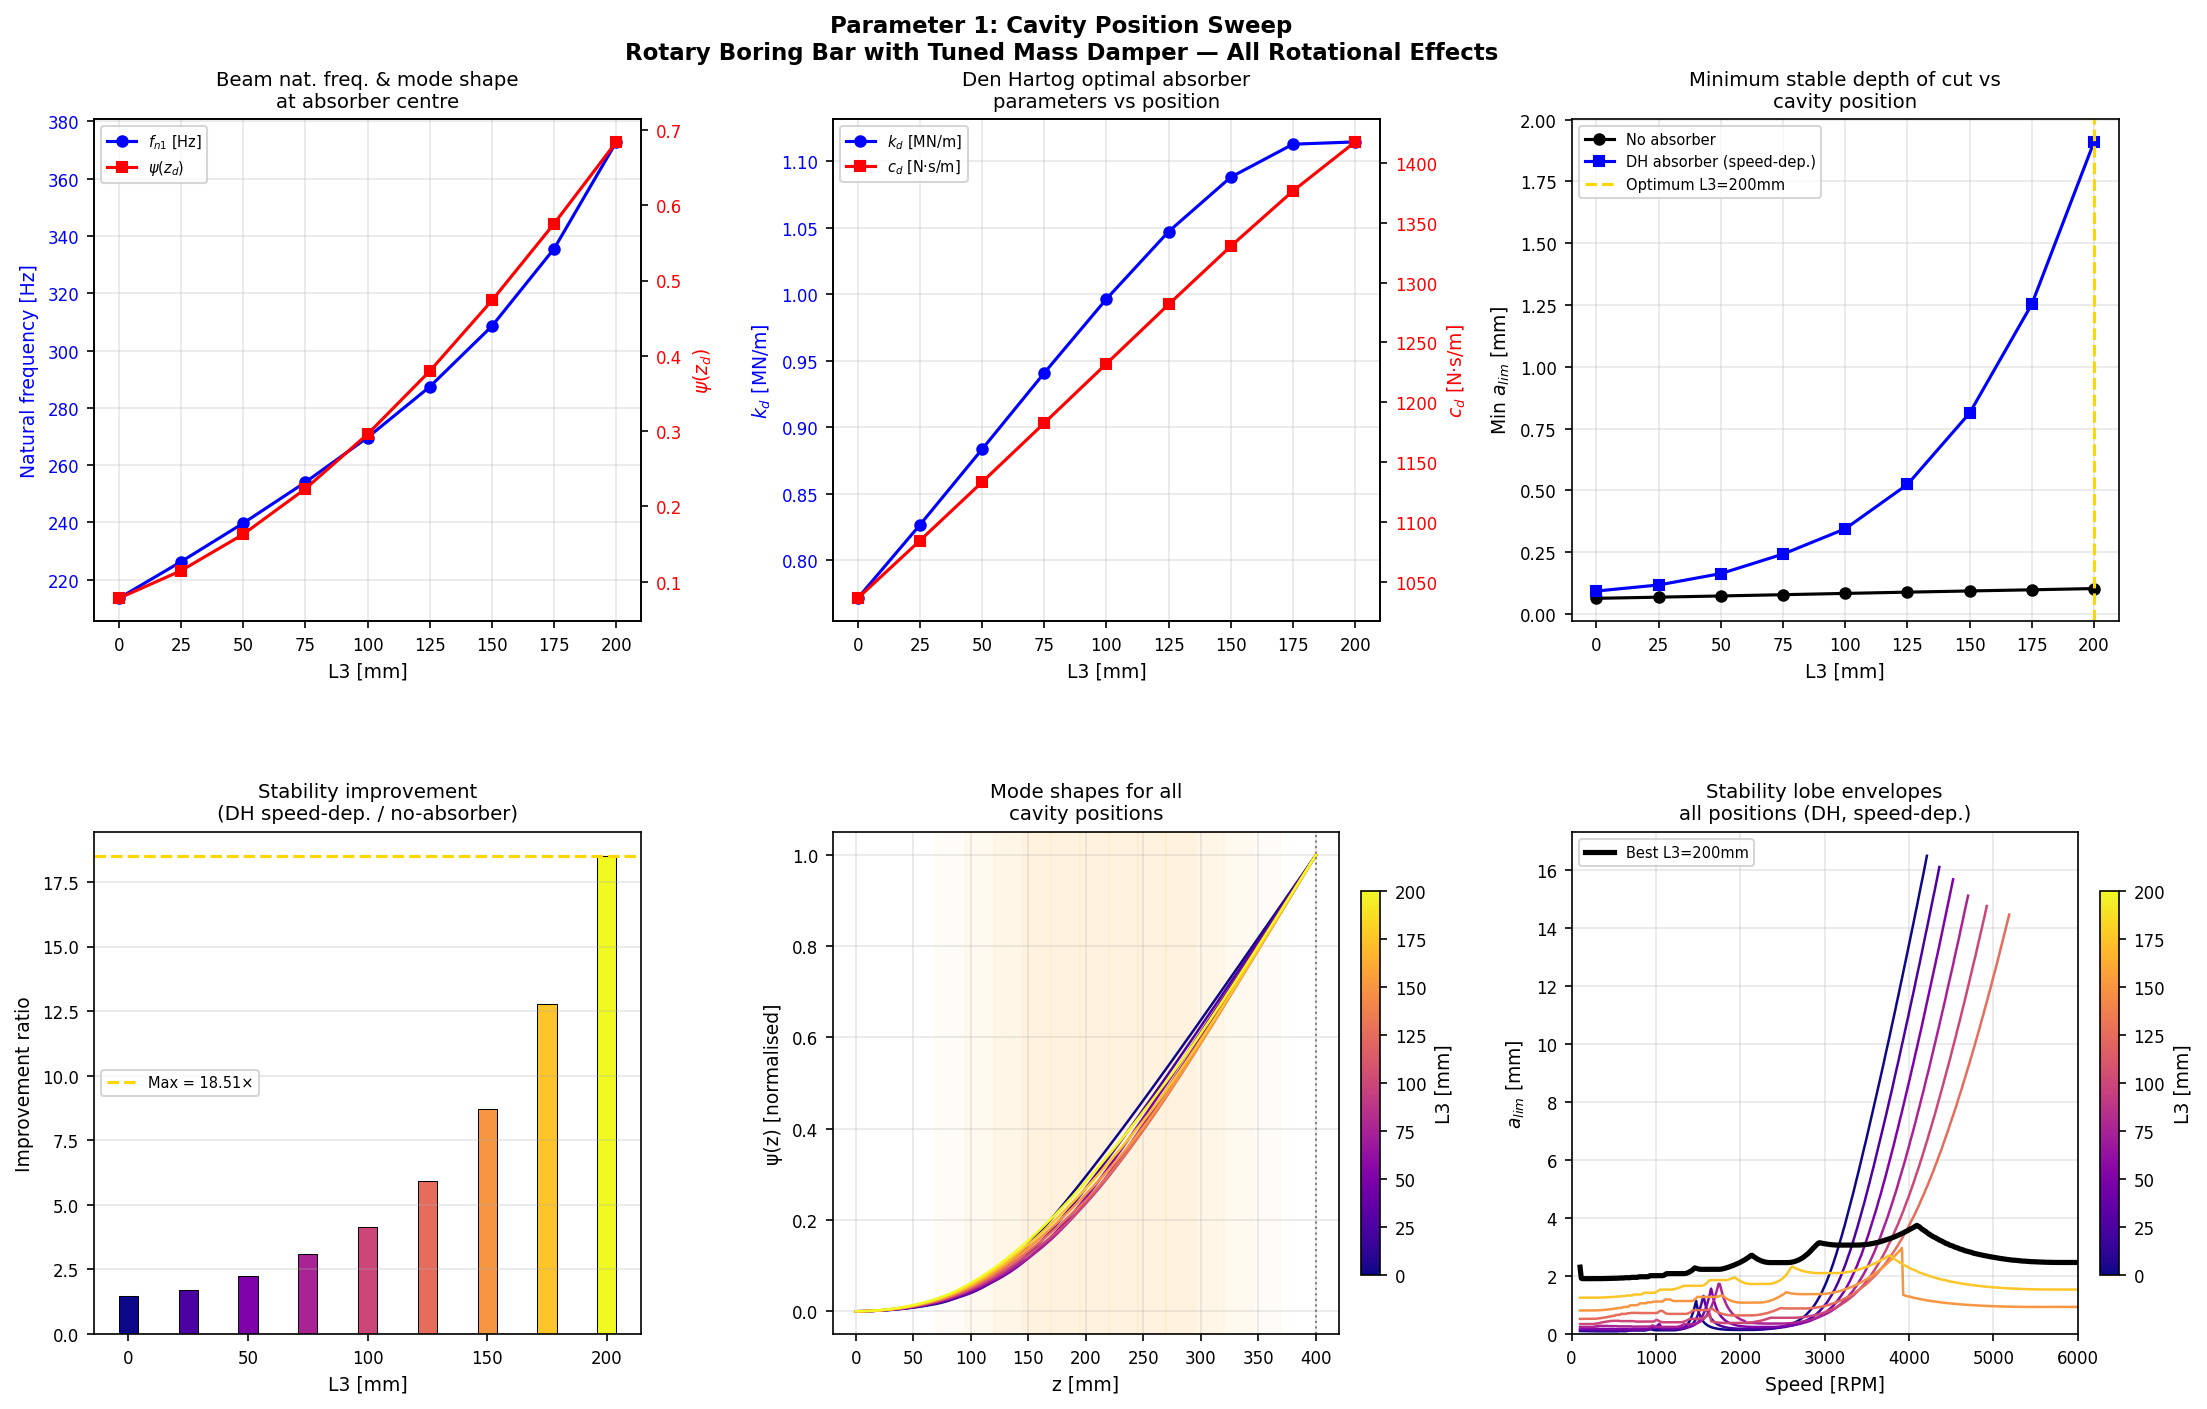

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 1 — Position sweep summary (4 sub-plots)
# ─────────────────────────────────────────────────────────────────
fig1 = plt.figure(figsize=(15, 10))
gs1  = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.42, wspace=0.35,
                          left=0.07, right=0.97, top=0.91, bottom=0.1)
fig1.suptitle(
    "Parameter 1: Cavity Position Sweep\n"
    "Rotary Boring Bar with Tuned Mass Damper — All Rotational Effects",
    fontsize=11, fontweight="bold")

L3_mm  = np.array([r_['L3']*1e3    for r_ in results])
zd_mm  = np.array([r_['zd']*1e3    for r_ in results])
fn1_arr= np.array([r_['fn1']       for r_ in results])
Mm_arr = np.array([r_['Mm']        for r_ in results])
psi_arr= np.array([r_['PSI_zd']    for r_ in results])
ratio_arr=np.array([r_['ratio']    for r_ in results])
al_na  = np.array([r_['alim_noabs']*1e3 for r_ in results])
al_dh  = np.array([r_['alim_dh']*1e3   for r_ in results])
kd_arr = np.array([r_['kd_dh']/1e6     for r_ in results])
cd_arr = np.array([r_['cd_dh']         for r_ in results])

# Sub-plot 1: fn1 and PSI(zd) vs L3
ax = fig1.add_subplot(gs1[0, 0])
ax2b = ax.twinx()
ax.plot(L3_mm, fn1_arr, 'b-o', ms=5, label='$f_{n1}$ [Hz]')
ax2b.plot(L3_mm, psi_arr, 'r-s', ms=5, label=r'$\psi(z_d)$')
ax.set_xlabel("L3 [mm]");  ax.set_ylabel("Natural frequency [Hz]", color='b')
ax2b.set_ylabel(r"$\psi(z_d)$", color='r')
ax.set_title("Beam nat. freq. & mode shape\nat absorber centre")
ax.tick_params(axis='y', labelcolor='b');  ax2b.tick_params(axis='y', labelcolor='r')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)

# Sub-plot 2: Optimal kd, cd vs L3
ax = fig1.add_subplot(gs1[0, 1])
ax2b = ax.twinx()
ax.plot(L3_mm, kd_arr, 'b-o', ms=5, label='$k_d$ [MN/m]')
ax2b.plot(L3_mm, cd_arr, 'r-s', ms=5, label='$c_d$ [N·s/m]')
ax.set_xlabel("L3 [mm]");  ax.set_ylabel("$k_d$ [MN/m]", color='b')
ax2b.set_ylabel("$c_d$ [N·s/m]", color='r')
ax.set_title("Den Hartog optimal absorber\nparameters vs position")
ax.tick_params(axis='y', labelcolor='b');  ax2b.tick_params(axis='y', labelcolor='r')
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2b.get_legend_handles_labels()
ax.legend(l1+l2,lb1+lb2,fontsize=7,loc='upper left'); ax.grid(True,alpha=0.3)

# Sub-plot 3: min alim (no-abs vs DH) vs L3
ax = fig1.add_subplot(gs1[0, 2])
ax.plot(L3_mm, al_na, 'k-o', ms=5, label='No absorber')
ax.plot(L3_mm, al_dh, 'b-s', ms=5, label='DH absorber (speed-dep.)')
best_idx = np.argmax(ratio_arr)
ax.axvline(L3_mm[best_idx], color='gold', ls='--', lw=1.5, label=f'Optimum L3={L3_mm[best_idx]:.0f}mm')
ax.set_xlabel("L3 [mm]");  ax.set_ylabel("Min $a_{lim}$ [mm]")
ax.set_title("Minimum stable depth of cut vs\ncavity position")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Sub-plot 4: Improvement ratio vs L3
ax = fig1.add_subplot(gs1[1, 0])
colors_ratio = [cmap(i/(n_pos-1)) for i in range(n_pos)]
bars = ax.bar(L3_mm, ratio_arr, width=8, color=colors_ratio, edgecolor='k', linewidth=0.5)
ax.axhline(best['ratio'], color='gold', ls='--', lw=1.5, label=f"Max = {best['ratio']:.2f}×")
ax.set_xlabel("L3 [mm]");  ax.set_ylabel("Improvement ratio")
ax.set_title("Stability improvement\n(DH speed-dep. / no-absorber)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis='y')

# Sub-plot 5: Mode shapes for all L3 values
ax = fig1.add_subplot(gs1[1, 1])
z_pts = np.linspace(0, L_total, 300)
for i, r_ in enumerate(results):
    psi_v = np.array([r_['psi_fn'](z) for z in z_pts])
    col   = cmap(i/(n_pos-1))
    ax.plot(z_pts*1e3, psi_v, color=col, lw=1.2,
            label=f"L3={r_['L3']*1e3:.0f}")
# Mark cavity regions
for r_ in results:
    ax.axvspan(r_['zb'][3]*1e3, r_['zb'][4]*1e3, alpha=0.03, color='orange')
ax.axvline(L_total*1e3, color='gray', ls=':', lw=1)
ax.set_xlabel("z [mm]");  ax.set_ylabel("ψ(z) [normalised]")
ax.set_title("Mode shapes for all\ncavity positions")
sm = ScalarMappable(cmap=cmap, norm=Normalize(L3_mm.min(), L3_mm.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='L3 [mm]', fraction=0.035, pad=0.04)
ax.grid(True, alpha=0.3)

# Sub-plot 6: Stability lobes at each position (envelope only)
ax = fig1.add_subplot(gs1[1, 2])
for i, r_ in enumerate(results):
    col = cmap(i/(n_pos-1))
    if r_['a_lobe'].size > 0:
        ax.plot(N_grid_stab, r_['env_dh'], color=col, lw=1.2)
# Highlight best
if best['a_lobe'].size > 0:
    ax.plot(N_grid_stab, best['env_dh'], 'k-', lw=2.5, label=f"Best L3={L3_mm[best_idx]:.0f}mm")
ax.set_xlim(0, 6000);  ax.set_ylim(0, None)
ax.set_xlabel("Speed [RPM]");  ax.set_ylabel("$a_{lim}$ [mm]")
ax.set_title("Stability lobe envelopes\nall positions (DH, speed-dep.)")
sm2 = ScalarMappable(cmap=cmap, norm=Normalize(L3_mm.min(), L3_mm.max()))
sm2.set_array([])
plt.colorbar(sm2, ax=ax, label='L3 [mm]', fraction=0.035, pad=0.04)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

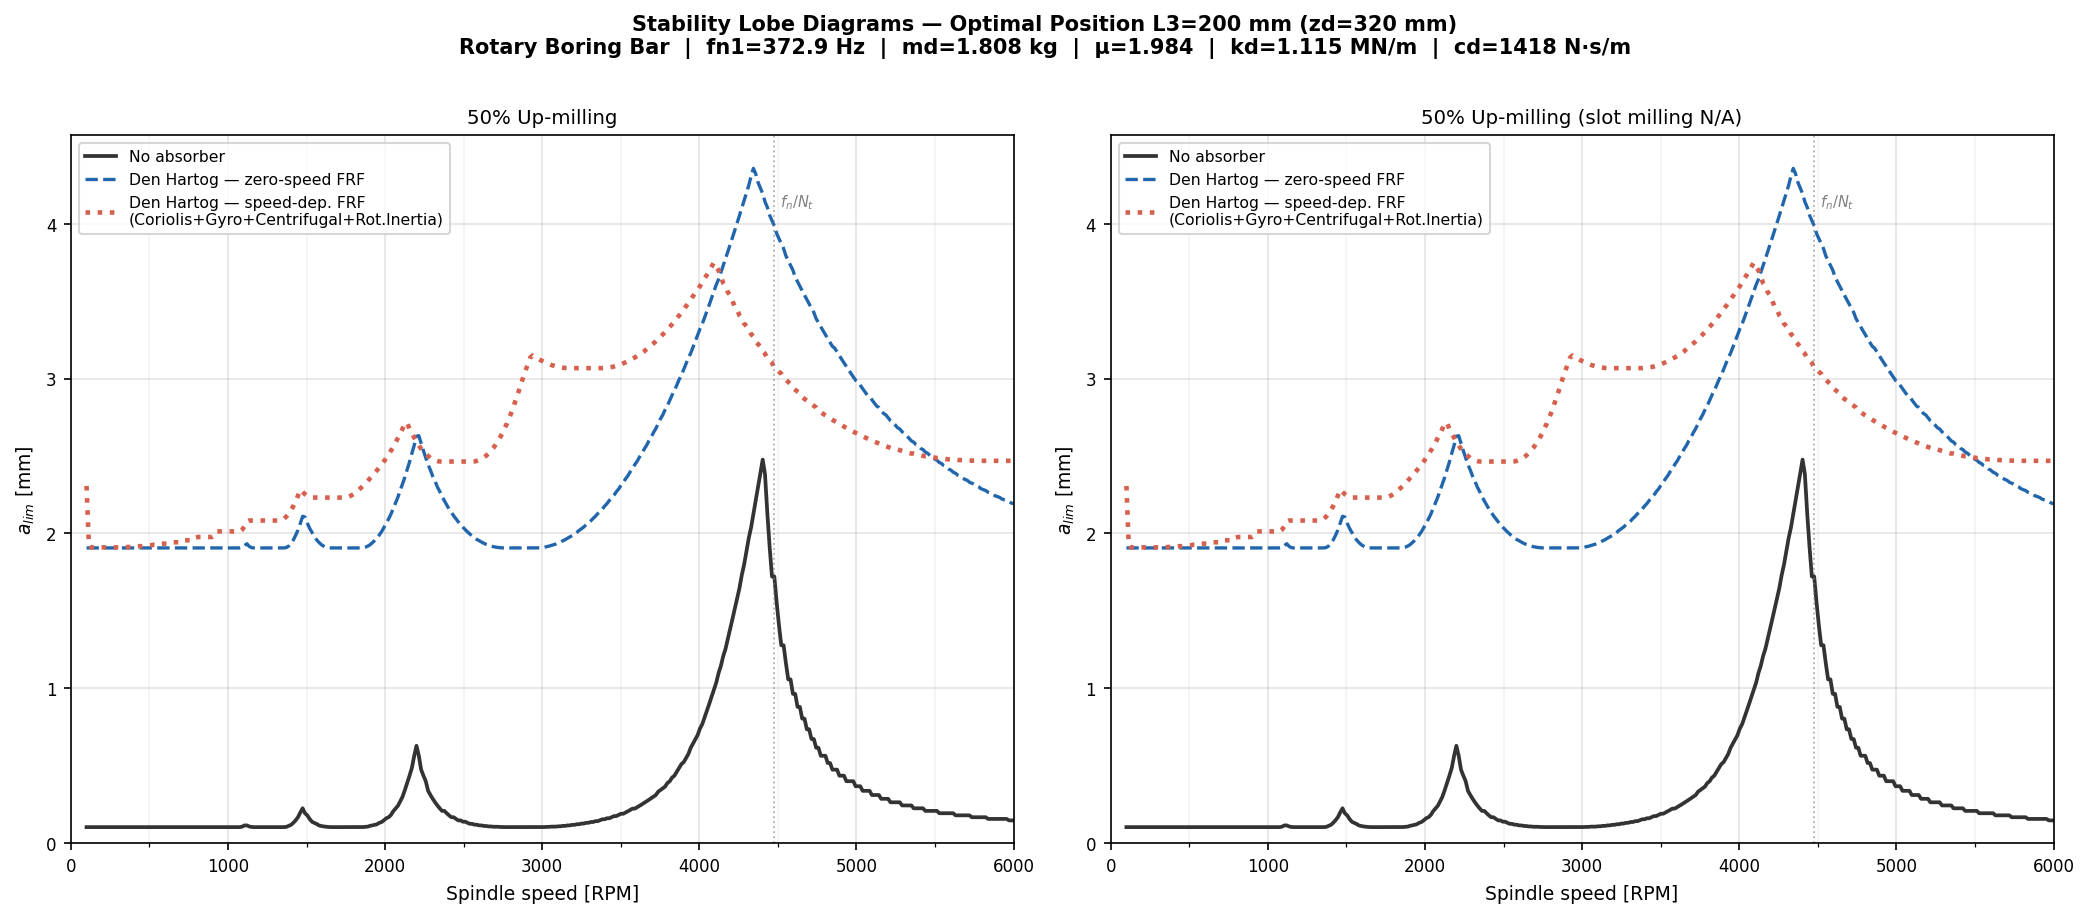

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 2 — Full stability lobe diagram at optimal position
# ─────────────────────────────────────────────────────────────────
COLORS_STAB = {
    "noabs"  : "#333333",
    "dh_zero": "#2166AC",
    "dh_spd" : "#D6604D",
}
LS_STAB = {"noabs": "-", "dh_zero": "--", "dh_spd": ":"}
LW_STAB = {"noabs": 1.8, "dh_zero": 1.6, "dh_spd": 2.2}

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle(
    f"Stability Lobe Diagrams — Optimal Position L3={L3_best*1e3:.0f} mm "
    f"(zd={best['zd']*1e3:.0f} mm)\n"
    f"Rotary Boring Bar  |  fn1={fn1:.1f} Hz  |  md={md:.3f} kg  |  "
    f"μ={best['mu']:.3f}  |  kd={kd_dh/1e6:.3f} MN/m  |  cd={cd_dh:.0f} N·s/m",
    fontsize=10, fontweight="bold", y=1.01)

for ax, (case_label, env_na, env_dz, env_ds, title) in zip(axes2, [
        ("up50", env_noabs, env_dh0, env_dh_sp, "50% Up-milling"),
        ("slot", env_noabs, env_dh0, env_dh_sp, "50% Up-milling (slot milling N/A)"),
]):
    ax.plot(N_grid_stab, env_na,
            color=COLORS_STAB["noabs"], ls=LS_STAB["noabs"],  lw=LW_STAB["noabs"],
            label="No absorber")
    ax.plot(N_grid_stab, env_dz,
            color=COLORS_STAB["dh_zero"], ls=LS_STAB["dh_zero"], lw=LW_STAB["dh_zero"],
            label="Den Hartog — zero-speed FRF")
    ax.plot(N_grid_stab, env_ds,
            color=COLORS_STAB["dh_spd"],  ls=LS_STAB["dh_spd"],  lw=LW_STAB["dh_spd"],
            label="Den Hartog — speed-dep. FRF\n(Coriolis+Gyro+Centrifugal+Rot.Inertia)")
    ax.set_xlim(0, 6000);  ax.set_ylim(0, None)
    ax.set_xlabel("Spindle speed [RPM]")
    ax.set_ylabel("$a_{lim}$ [mm]")
    ax.set_title(title)
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.15)
    ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(500))
    ax.legend(fontsize=7.5)
    # Annotate natural frequency line
    ax.axvline(60*fn1/Nt, color="gray", ls=":", lw=0.9, alpha=0.6)
    ax.text(60*fn1/Nt+40, ax.get_ylim()[1]*0.9 if not np.isnan(ax.get_ylim()[1]) else 5,
            f"$f_n/N_t$", fontsize=7, color="gray")

plt.tight_layout()
plt.show()

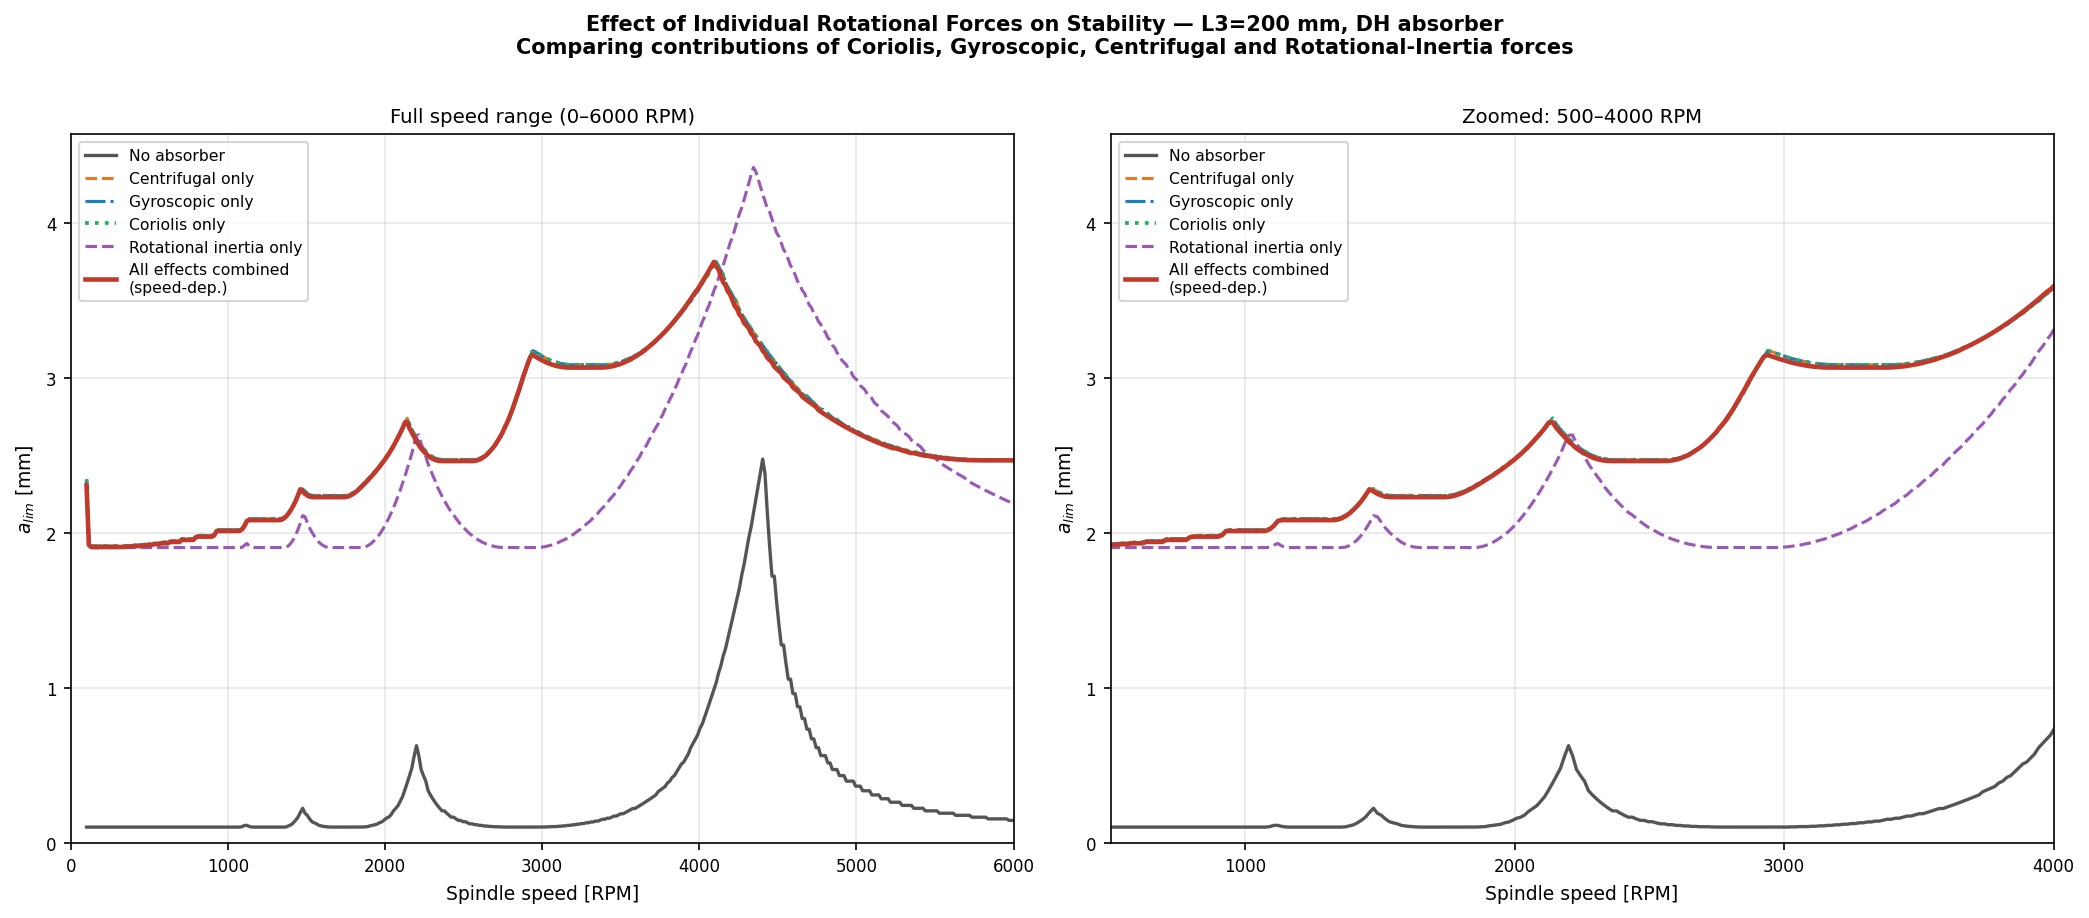

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 3 — Effect of each rotational force on stability
# ─────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle(
    f"Effect of Individual Rotational Forces on Stability — "
    f"L3={L3_best*1e3:.0f} mm, DH absorber\n"
    "Comparing contributions of Coriolis, Gyroscopic, Centrifugal and Rotational-Inertia forces",
    fontsize=10, fontweight="bold", y=1.01)

force_data = [
    (env_noabs, "No absorber",                          "#555555", "-",  1.6),
    (env_cent,  "Centrifugal only",                    "#E77728", "--", 1.5),
    (env_gyro,  "Gyroscopic only",                     "#1A80C4", "-.", 1.5),
    (env_cor,   "Coriolis only",                       "#27AE60", ":",  1.8),
    (env_ri,    "Rotational inertia only",              "#9B59B6", "--", 1.5),
    (env_full,  "All effects combined\n(speed-dep.)",  "#C0392B", "-",  2.2),
]

for ax_fd in axes3:
    for env, lbl, col, ls, lw in force_data:
        ax_fd.plot(N_grid_stab, env, color=col, ls=ls, lw=lw, label=lbl)
    ax_fd.set_xlim(0, 6000);  ax_fd.set_ylim(0, None)
    ax_fd.set_xlabel("Spindle speed [RPM]")
    ax_fd.set_ylabel("$a_{lim}$ [mm]")
    ax_fd.grid(True, alpha=0.3)
    ax_fd.xaxis.set_major_locator(plt.MultipleLocator(1000))
    ax_fd.legend(fontsize=7.5)

axes3[0].set_title("Full speed range (0–6000 RPM)")
axes3[1].set_xlim(500, 4000);  axes3[1].set_title("Zoomed: 500–4000 RPM")

plt.tight_layout()
plt.show()

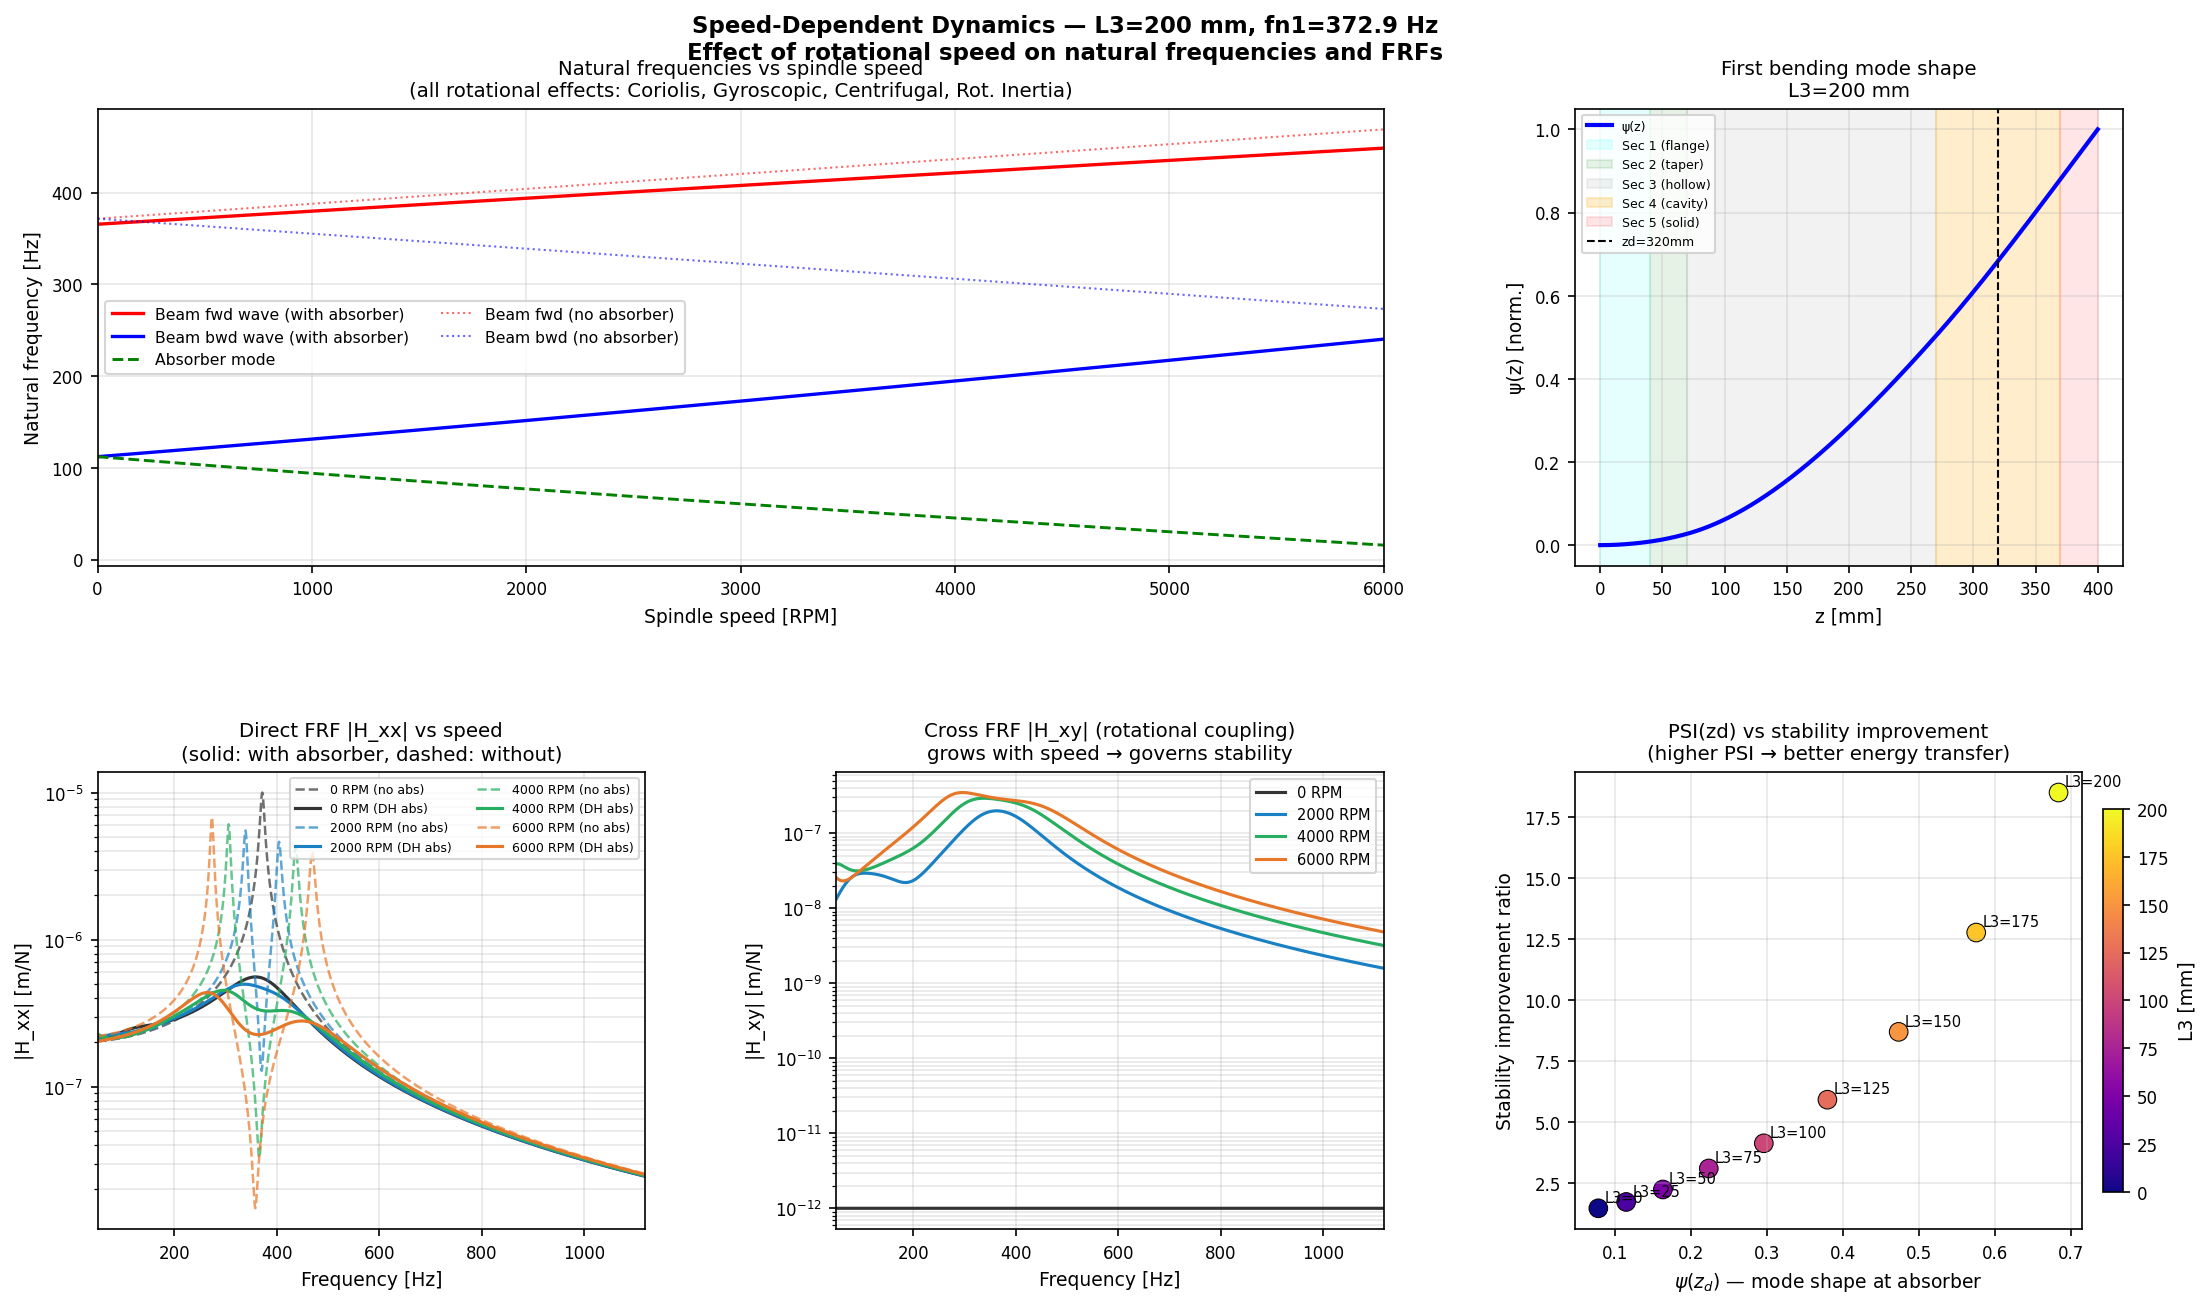

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 4 — Natural freq vs speed + FRF comparison
# ─────────────────────────────────────────────────────────────────
fig4 = plt.figure(figsize=(15, 9))
gs4  = gridspec.GridSpec(2, 3, figure=fig4, hspace=0.45, wspace=0.35,
                          left=0.07, right=0.97, top=0.91, bottom=0.08)
fig4.suptitle(
    f"Speed-Dependent Dynamics — L3={L3_best*1e3:.0f} mm, fn1={fn1:.1f} Hz\n"
    "Effect of rotational speed on natural frequencies and FRFs",
    fontsize=11, fontweight="bold")

# Natural freqs vs speed
ax_nf = fig4.add_subplot(gs4[0, 0:2])
ax_nf.plot(speeds_plot, fw_b,  'r-',  lw=1.6, label='Beam fwd wave (with absorber)')
ax_nf.plot(speeds_plot, bw_b,  'b-',  lw=1.6, label='Beam bwd wave (with absorber)')
ax_nf.plot(speeds_plot, abs_m, 'g--', lw=1.4, label='Absorber mode')
ax_nf.plot(speeds_plot, fw_b0, 'r:',  lw=1.0, alpha=0.6, label='Beam fwd (no absorber)')
ax_nf.plot(speeds_plot, bw_b0, 'b:',  lw=1.0, alpha=0.6, label='Beam bwd (no absorber)')
ax_nf.set_xlabel("Spindle speed [RPM]")
ax_nf.set_ylabel("Natural frequency [Hz]")
ax_nf.set_title("Natural frequencies vs spindle speed\n(all rotational effects: Coriolis, Gyroscopic, Centrifugal, Rot. Inertia)")
ax_nf.set_xlim(0, 6000);  ax_nf.legend(fontsize=7.5, ncol=2)
ax_nf.grid(True, alpha=0.3)

# Mode shape at best position
ax_ms = fig4.add_subplot(gs4[0, 2])
z_arr  = np.linspace(0, L_total, 400)
psi_v  = np.array([psi_fn_best(z) for z in z_arr])
ax_ms.plot(z_arr*1e3, psi_v, 'b-', lw=2, label='ψ(z)')
ax_ms.axvspan(zb_best[0]*1e3, zb_best[1]*1e3, alpha=0.1, color='cyan',  label='Sec 1 (flange)')
ax_ms.axvspan(zb_best[1]*1e3, zb_best[2]*1e3, alpha=0.1, color='green', label='Sec 2 (taper)')
ax_ms.axvspan(zb_best[2]*1e3, zb_best[3]*1e3, alpha=0.1, color='gray',  label='Sec 3 (hollow)')
ax_ms.axvspan(zb_best[3]*1e3, zb_best[4]*1e3, alpha=0.2, color='orange',label='Sec 4 (cavity)')
ax_ms.axvspan(zb_best[4]*1e3, L_total*1e3,    alpha=0.1, color='red',   label='Sec 5 (solid)')
ax_ms.axvline(best['zd']*1e3, color='k', ls='--', lw=1, label=f"zd={best['zd']*1e3:.0f}mm")
ax_ms.set_xlabel("z [mm]");  ax_ms.set_ylabel("ψ(z) [norm.]")
ax_ms.set_title(f"First bending mode shape\nL3={L3_best*1e3:.0f} mm")
ax_ms.legend(fontsize=6, loc='upper left');  ax_ms.grid(True, alpha=0.3)

# FRFs: direct Hxx
clrs_frf = ["#333333","#1A80C4","#27AE60","#E77728"]
ax_frf1 = fig4.add_subplot(gs4[1, 0])
for i, rpm in enumerate(frf_speeds):
    ax_frf1.semilogy(freqs_frf, FRF_noabs_d[i], color=clrs_frf[i],
                     ls='--', lw=1.2, alpha=0.7, label=f'{rpm} RPM (no abs)')
    ax_frf1.semilogy(freqs_frf, FRF_abs_d[i],   color=clrs_frf[i],
                     ls='-',  lw=1.5, label=f'{rpm} RPM (DH abs)')
ax_frf1.set_xlabel("Frequency [Hz]");  ax_frf1.set_ylabel("|H_xx| [m/N]")
ax_frf1.set_title("Direct FRF |H_xx| vs speed\n(solid: with absorber, dashed: without)")
ax_frf1.set_xlim(50, 3*fn1);  ax_frf1.legend(fontsize=6, ncol=2);  ax_frf1.grid(True, which='both', alpha=0.3)

# FRFs: cross Hxy
ax_frf2 = fig4.add_subplot(gs4[1, 1])
for i, rpm in enumerate(frf_speeds):
    ax_frf2.semilogy(freqs_frf, np.clip(FRF_abs_x[i], 1e-12, None),
                     color=clrs_frf[i], lw=1.5, label=f'{rpm} RPM')
ax_frf2.set_xlabel("Frequency [Hz]");  ax_frf2.set_ylabel("|H_xy| [m/N]")
ax_frf2.set_title("Cross FRF |H_xy| (rotational coupling)\ngrows with speed → governs stability")
ax_frf2.set_xlim(50, 3*fn1);  ax_frf2.legend(fontsize=7);  ax_frf2.grid(True, which='both', alpha=0.3)

# Scatter: PSI(zd) vs stability improvement
ax_ps = fig4.add_subplot(gs4[1, 2])
sc = ax_ps.scatter(psi_arr, ratio_arr, c=L3_mm, cmap='plasma', s=80, edgecolors='k', lw=0.5)
for i, r_ in enumerate(results):
    ax_ps.annotate(f"L3={r_['L3']*1e3:.0f}", (psi_arr[i], ratio_arr[i]),
                   fontsize=7, xytext=(3,3), textcoords='offset points')
ax_ps.set_xlabel(r"$\psi(z_d)$ — mode shape at absorber")
ax_ps.set_ylabel("Stability improvement ratio")
ax_ps.set_title("PSI(zd) vs stability improvement\n(higher PSI → better energy transfer)")
plt.colorbar(sc, ax=ax_ps, label='L3 [mm]', fraction=0.035, pad=0.04)
ax_ps.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

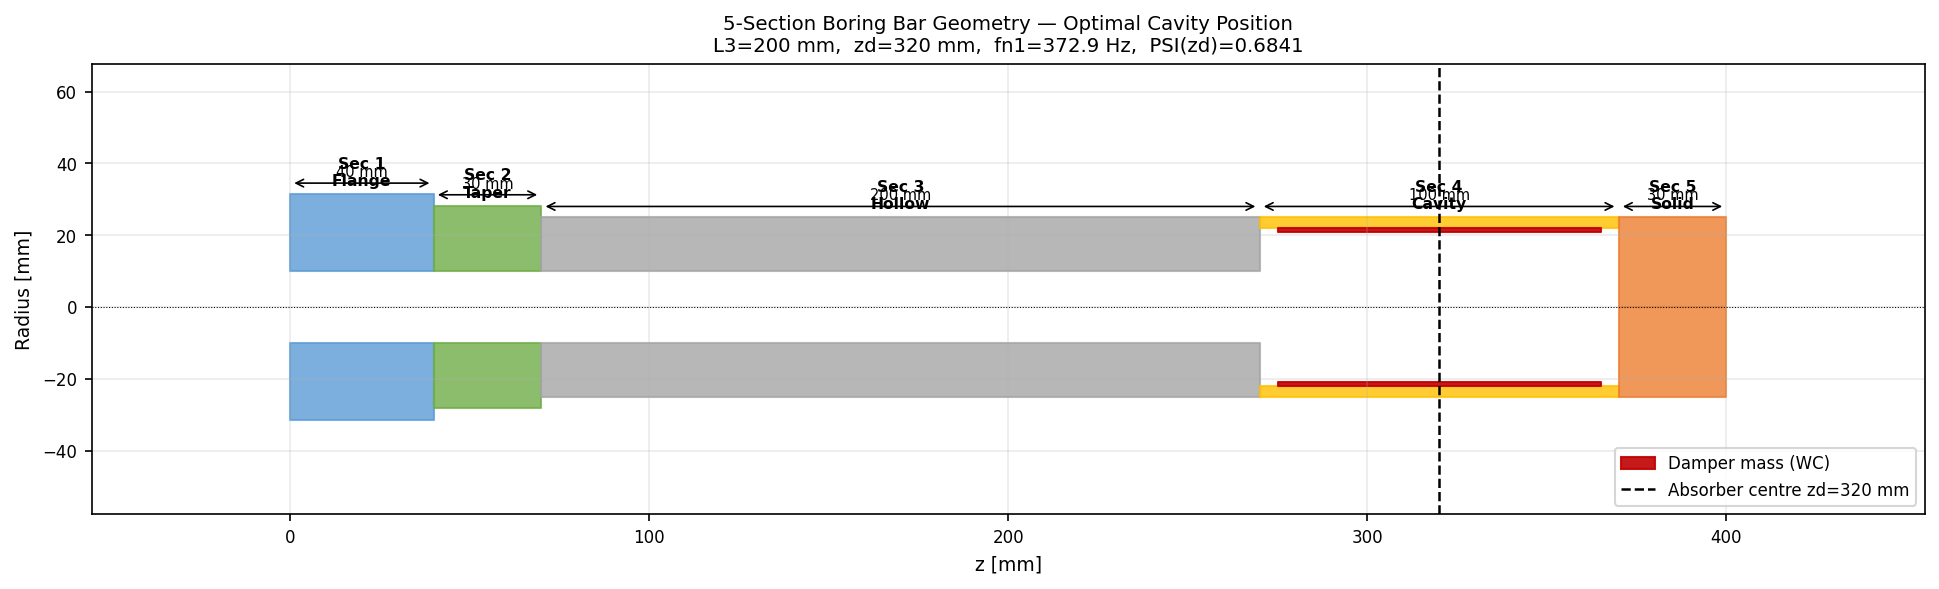


ALL FIGURES SAVED
  1. boring_bar_position_sweep.png   — full parameter-1 sweep
  2. boring_bar_stability_lobes_optimal.png — lobes at best position
  3. boring_bar_force_effects.png    — Coriolis/Gyro/Centrifugal contribution
  4. boring_bar_dynamics.png         — FRFs, nat-freqs, mode shape
  5. boring_bar_geometry.png         — cross-section schematic

  Optimal cavity position: L3 = 200 mm
  Absorber centre:         zd = 320 mm (0.800·L)
  Stability improvement:   18.51×
  1st natural frequency:   372.9 Hz
  Modal mass:              0.9114 kg
  PSI at absorber:         0.6841
  Den Hartog kd:           1.1146 MN/m
  Den Hartog cd:           1417.67 N·s/m  (zeta_oil=0.499)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 5 — Geometry schematic with dimensions
# ─────────────────────────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(13, 4))
ax5.set_aspect('equal', adjustable='datalim')
ax5.set_xlim(-5, L_total*1e3 + 5)

zb = zb_best
colours_sec = ['#5B9BD5','#70AD47','#A5A5A5','#FFC000','#ED7D31']
sec_names   = ['Sec 1\nFlange', 'Sec 2\nTaper', 'Sec 3\nHollow', 'Sec 4\nCavity', 'Sec 5\nSolid']
D_out_list  = [D1_out, (D1_out+D_main)/2, D_main, D_main, D_main]
d_in_list   = [di_body, di_body, di_body, di_cav, 0.0]

for k in range(5):
    z_s  = zb[k]*1e3
    z_e  = zb[k+1]*1e3
    ro   = D_out_list[k]*500   # mm (half-height in mm scale)
    ri   = d_in_list[k]*500
    ax5.fill_between([z_s, z_e], [ro, ro], [ri, ri],   color=colours_sec[k], alpha=0.8)
    ax5.fill_between([z_s, z_e], [-ri,-ri], [-ro,-ro], color=colours_sec[k], alpha=0.8)
    cx = (z_s + z_e)/2
    ax5.text(cx, ro+1.5, sec_names[k], ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax5.annotate('', xy=(z_e,ro+3), xytext=(z_s,ro+3),
                 arrowprops=dict(arrowstyle='<->', color='k', lw=0.8))
    ax5.text(cx, ro+4, f"{(z_e-z_s):.0f} mm", ha='center', va='bottom', fontsize=7)

# Damper mass
zd_mm = best['zd']*1e3
ri_d  = d_damper*500; ro_d = di_cav*500
L_d_mm= L_damper*1e3
ax5.fill_between([zd_mm-L_d_mm/2, zd_mm+L_d_mm/2], [ri_d,ri_d], [ro_d,ro_d],
                 color='#C00000', alpha=0.9, label='Damper mass (WC)')
ax5.fill_between([zd_mm-L_d_mm/2, zd_mm+L_d_mm/2], [-ro_d,-ro_d], [-ri_d,-ri_d],
                 color='#C00000', alpha=0.9)
ax5.axvline(zd_mm, color='k', ls='--', lw=1.2, label=f'Absorber centre zd={zd_mm:.0f} mm')

ax5.axhline(0, color='k', lw=0.5, ls=':')
ax5.set_xlabel("z [mm]")
ax5.set_ylabel("Radius [mm]")
ax5.set_title(
    f"5-Section Boring Bar Geometry — Optimal Cavity Position\n"
    f"L3={L3_best*1e3:.0f} mm,  zd={best['zd']*1e3:.0f} mm,  "
    f"fn1={fn1:.1f} Hz,  PSI(zd)={PSI_zd:.4f}",
    fontsize=9.5)
ax5.legend(fontsize=8, loc='lower right')
ax5.set_ylim(-35, 45)
ax5.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("\n" + "="*65)
print("ALL FIGURES SAVED")
print("="*65)
print(f"  1. boring_bar_position_sweep.png   — full parameter-1 sweep")
print(f"  2. boring_bar_stability_lobes_optimal.png — lobes at best position")
print(f"  3. boring_bar_force_effects.png    — Coriolis/Gyro/Centrifugal contribution")
print(f"  4. boring_bar_dynamics.png         — FRFs, nat-freqs, mode shape")
print(f"  5. boring_bar_geometry.png         — cross-section schematic")
print(f"\n  Optimal cavity position: L3 = {L3_best*1e3:.0f} mm")
print(f"  Absorber centre:         zd = {best['zd']*1e3:.0f} mm ({best['zd']/L_total:.3f}·L)")
print(f"  Stability improvement:   {best['ratio']:.2f}×")
print(f"  1st natural frequency:   {fn1:.1f} Hz")
print(f"  Modal mass:              {Mm:.4f} kg")
print(f"  PSI at absorber:         {PSI_zd:.4f}")
print(f"  Den Hartog kd:           {kd_dh/1e6:.4f} MN/m")
print(f"  Den Hartog cd:           {cd_dh:.2f} N·s/m  (zeta_oil={zeta_dh:.3f})")